In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import cartopy.crs as ccrs

import sys
module_path = "../bin"
sys.path.insert(0,module_path)

import um_utils_plotting as umplt
import um_utils as um
import get_cpt
from geometry_fix import apply_geometry_collection_fix

apply_geometry_collection_fix()

np.set_printoptions(suppress=True)

um.WarningSuppress()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
#------------------------------------------------------------
# Functions for PFT litter calculation
#------------------------------------------------------------

def calc_lai_bal(ht, a_ws, eta_sl, a_wl, b_wl):
    a_ws = xr.DataArray(um.pft_params("a_ws"), dims="pseudo")
    eta_sl = xr.DataArray(um.pft_params("eta_sl"), dims="pseudo")
    a_wl = xr.DataArray(um.pft_params("a_wl"), dims="pseudo")
    b_wl = xr.DataArray(um.pft_params("b_wl"), dims="pseudo")

    lai_bal = (ht * a_ws * eta_sl / a_wl) ** (1.0 / (b_wl - 1.0))

    try: lai_bal = lai_bal.transpose(*ht.dims)
    except Exception: pass

    return lai_bal

def calc_leaf_turnover(ts,phen):
    tleaf = xr.DataArray(um.pft_params("tleaf"), dims="pseudo")
    dgl_dt = xr.DataArray(um.pft_params("dgl_dt"), dims="pseudo")
    g_leaf_0 = xr.DataArray(um.pft_params("g_leaf_0"), dims="pseudo")
    g_grow = xr.DataArray(um.pft_params("g_grow"), dims="pseudo")

    ts = xr.concat([ts] * 13, dim="pseudo")
    ft = xr.where(ts < tleaf, 1.0 + dgl_dt * (tleaf - ts), 1.0)

    g_lm = g_leaf_0 * ft

    g_leaf_phen = xr.where(
        g_lm > 2.0 * g_leaf_0,
        np.maximum(-g_grow, 0.01 - phen),
        np.minimum(-g_grow * (1.0 - phen), 1.0 - phen)
    )
    
    try: g_leaf_phen = g_leaf_phen.transpose(*phen.dims)
    except Exception: pass

    return g_leaf_phen

In [ ]:
# Coordinates
MH_means = um.importUMData(f"../Data/Monthly_Means/MH_monthly_means_197001-204912.nc")
PI_means = um.importUMData(f"../Data/Monthly_Means/PI_monthly_means_187001-194912.nc")

# Great-Plains Mask
GP_region = umplt.umRegion("GP")
GP_mask = umplt.umRegionMask("GP", MH_means.longitude, MH_means.latitude)


#--------------------------------------------------
# Great Plains PFT Fractions
#--------------------------------------------------

pft_idx = [[0, 2, 4, 3, 12], [4], [2], [12], [3], [0], [5, 6, 7], [8, 9, 10], [15]]
mh_gp_sfracs = np.zeros(len(pft_idx))
pi_gp_sfracs = np.zeros(len(pft_idx))
for i, idx in enumerate(pft_idx):
    mh_gp_sfracs[i] = MH_means["surfacefrac"][:, idx].where(GP_mask).sum(dim="surface_tiles", min_count=1).mean(dim=["time", "latitude", "longitude"]) * 100
    pi_gp_sfracs[i] = PI_means["surfacefrac"][:, idx].where(GP_mask).sum(dim="surface_tiles", min_count=1).mean(dim=["time", "latitude", "longitude"]) * 100


#--------------------------------------------------
# Bootstrap Soil Moisture
#--------------------------------------------------

sat_vol = um.importUMData(f"../Data/sat_vsmc_um13.2.nc")
layer_tickness = xr.DataArray([0.1, 0.25, 0.65, 2],dims="depth")

mhData = um.importUMData(f"../Data/Timeseries/MH/unfrozen_smc_197001-204912.nc")
piData = um.importUMData(f"../Data/Timeseries/PI/unfrozen_smc_187001-194912.nc")

mhData = (mhData * sat_vol * 1000 * layer_tickness).sum(dim="depth", min_count=1)
piData = (piData * sat_vol * 1000 * layer_tickness).sum(dim="depth", min_count=1)

gp_mhData = mhData.where(GP_mask).mean(dim=["latitude", "longitude"]).coarsen(time=12).construct(time=["year", "month"])
gp_piData = piData.where(GP_mask).mean(dim=["latitude", "longitude"]).coarsen(time=12).construct(time=["year", "month"])
sm_mon_mean, sm_ci_upper, sm_ci_lower = um.bootstrap_years_anom(gp_piData, gp_mhData)

#--------------------------------------------------
# Spatial Anomaly for Moisture Stress
#--------------------------------------------------

mh_beta = (MH_means["beta_factor"] * MH_means["surfacefrac"][:, :13].rename({"surface_tiles": "PFTs"})).sum(dim="PFTs", min_count=1).mean(dim="time")
pi_beta = (PI_means["beta_factor"] * PI_means["surfacefrac"][:, :13].rename({"surface_tiles": "PFTs"})).sum(dim="PFTs", min_count=1).mean(dim="time")
beta_anom = mh_beta - pi_beta

#--------------------------------------------------
# Great Plains NPP Change
#--------------------------------------------------

mh_gp_npp = MH_means["npp_nlimit_pft"].mean(dim="time").rename({"PFTs": "pseudo"}).where(GP_mask).mean(dim=["latitude", "longitude"])
pi_gp_npp = PI_means["npp_nlimit_pft"].mean(dim="time").rename({"PFTs": "pseudo"}).where(GP_mask).mean(dim=["latitude", "longitude"])

gp_npp_anom = (mh_gp_npp - pi_gp_npp) / pi_gp_npp * 100

#--------------------------------------------------
# NPP to Litterfall Ratios
#--------------------------------------------------

ht = PI_means["can_hgt"].mean(dim="time").rename({"PFTs": "pseudo"})
lai = PI_means["lai"].mean(dim="time").rename({"PFTs": "pseudo"})
veg_c = PI_means["veg_carbon_pft"].mean(dim="time").rename({"PFTs": "pseudo"})
ts = PI_means["ts"].mean(dim="time") + 273.15
leaf_c = PI_means["leaf_carbon_pft"].mean(dim="time").rename({"PFTs": "pseudo"})
root_c = PI_means["root_carbon_pft"].mean(dim="time").rename({"PFTs": "pseudo"})
wood_c = PI_means["wood_carbon_pft"].mean(dim="time").rename({"PFTs": "pseudo"})

lai_bal = calc_lai_bal(ht)
phen = lai / lai_bal
phen = phen.clip(0.0, 1.0)

g_leaf_0 = xr.DataArray(um.pft_params("g_leaf_0"), dims="pseudo")
g_root = xr.DataArray(um.pft_params("g_root"), dims="pseudo")
g_wood = xr.DataArray(um.pft_params("g_wood"), dims="pseudo")

g_leaf = calc_leaf_turnover(ts, phen)
g_leaf = xr.where(g_leaf < 0.0, g_leaf_0 * phen, g_leaf)

litter = (g_leaf * leaf_c) + (g_root * root_c) + (g_wood * wood_c)
npp = PI_means["npp_nlimit_pft"].mean(dim="time").rename({"PFTs": "pseudo"})

gp_npp_to_litter = npp.where(GP_mask).mean(dim=["latitude", "longitude"]) / litter.where(GP_mask).mean(dim=["latitude", "longitude"])

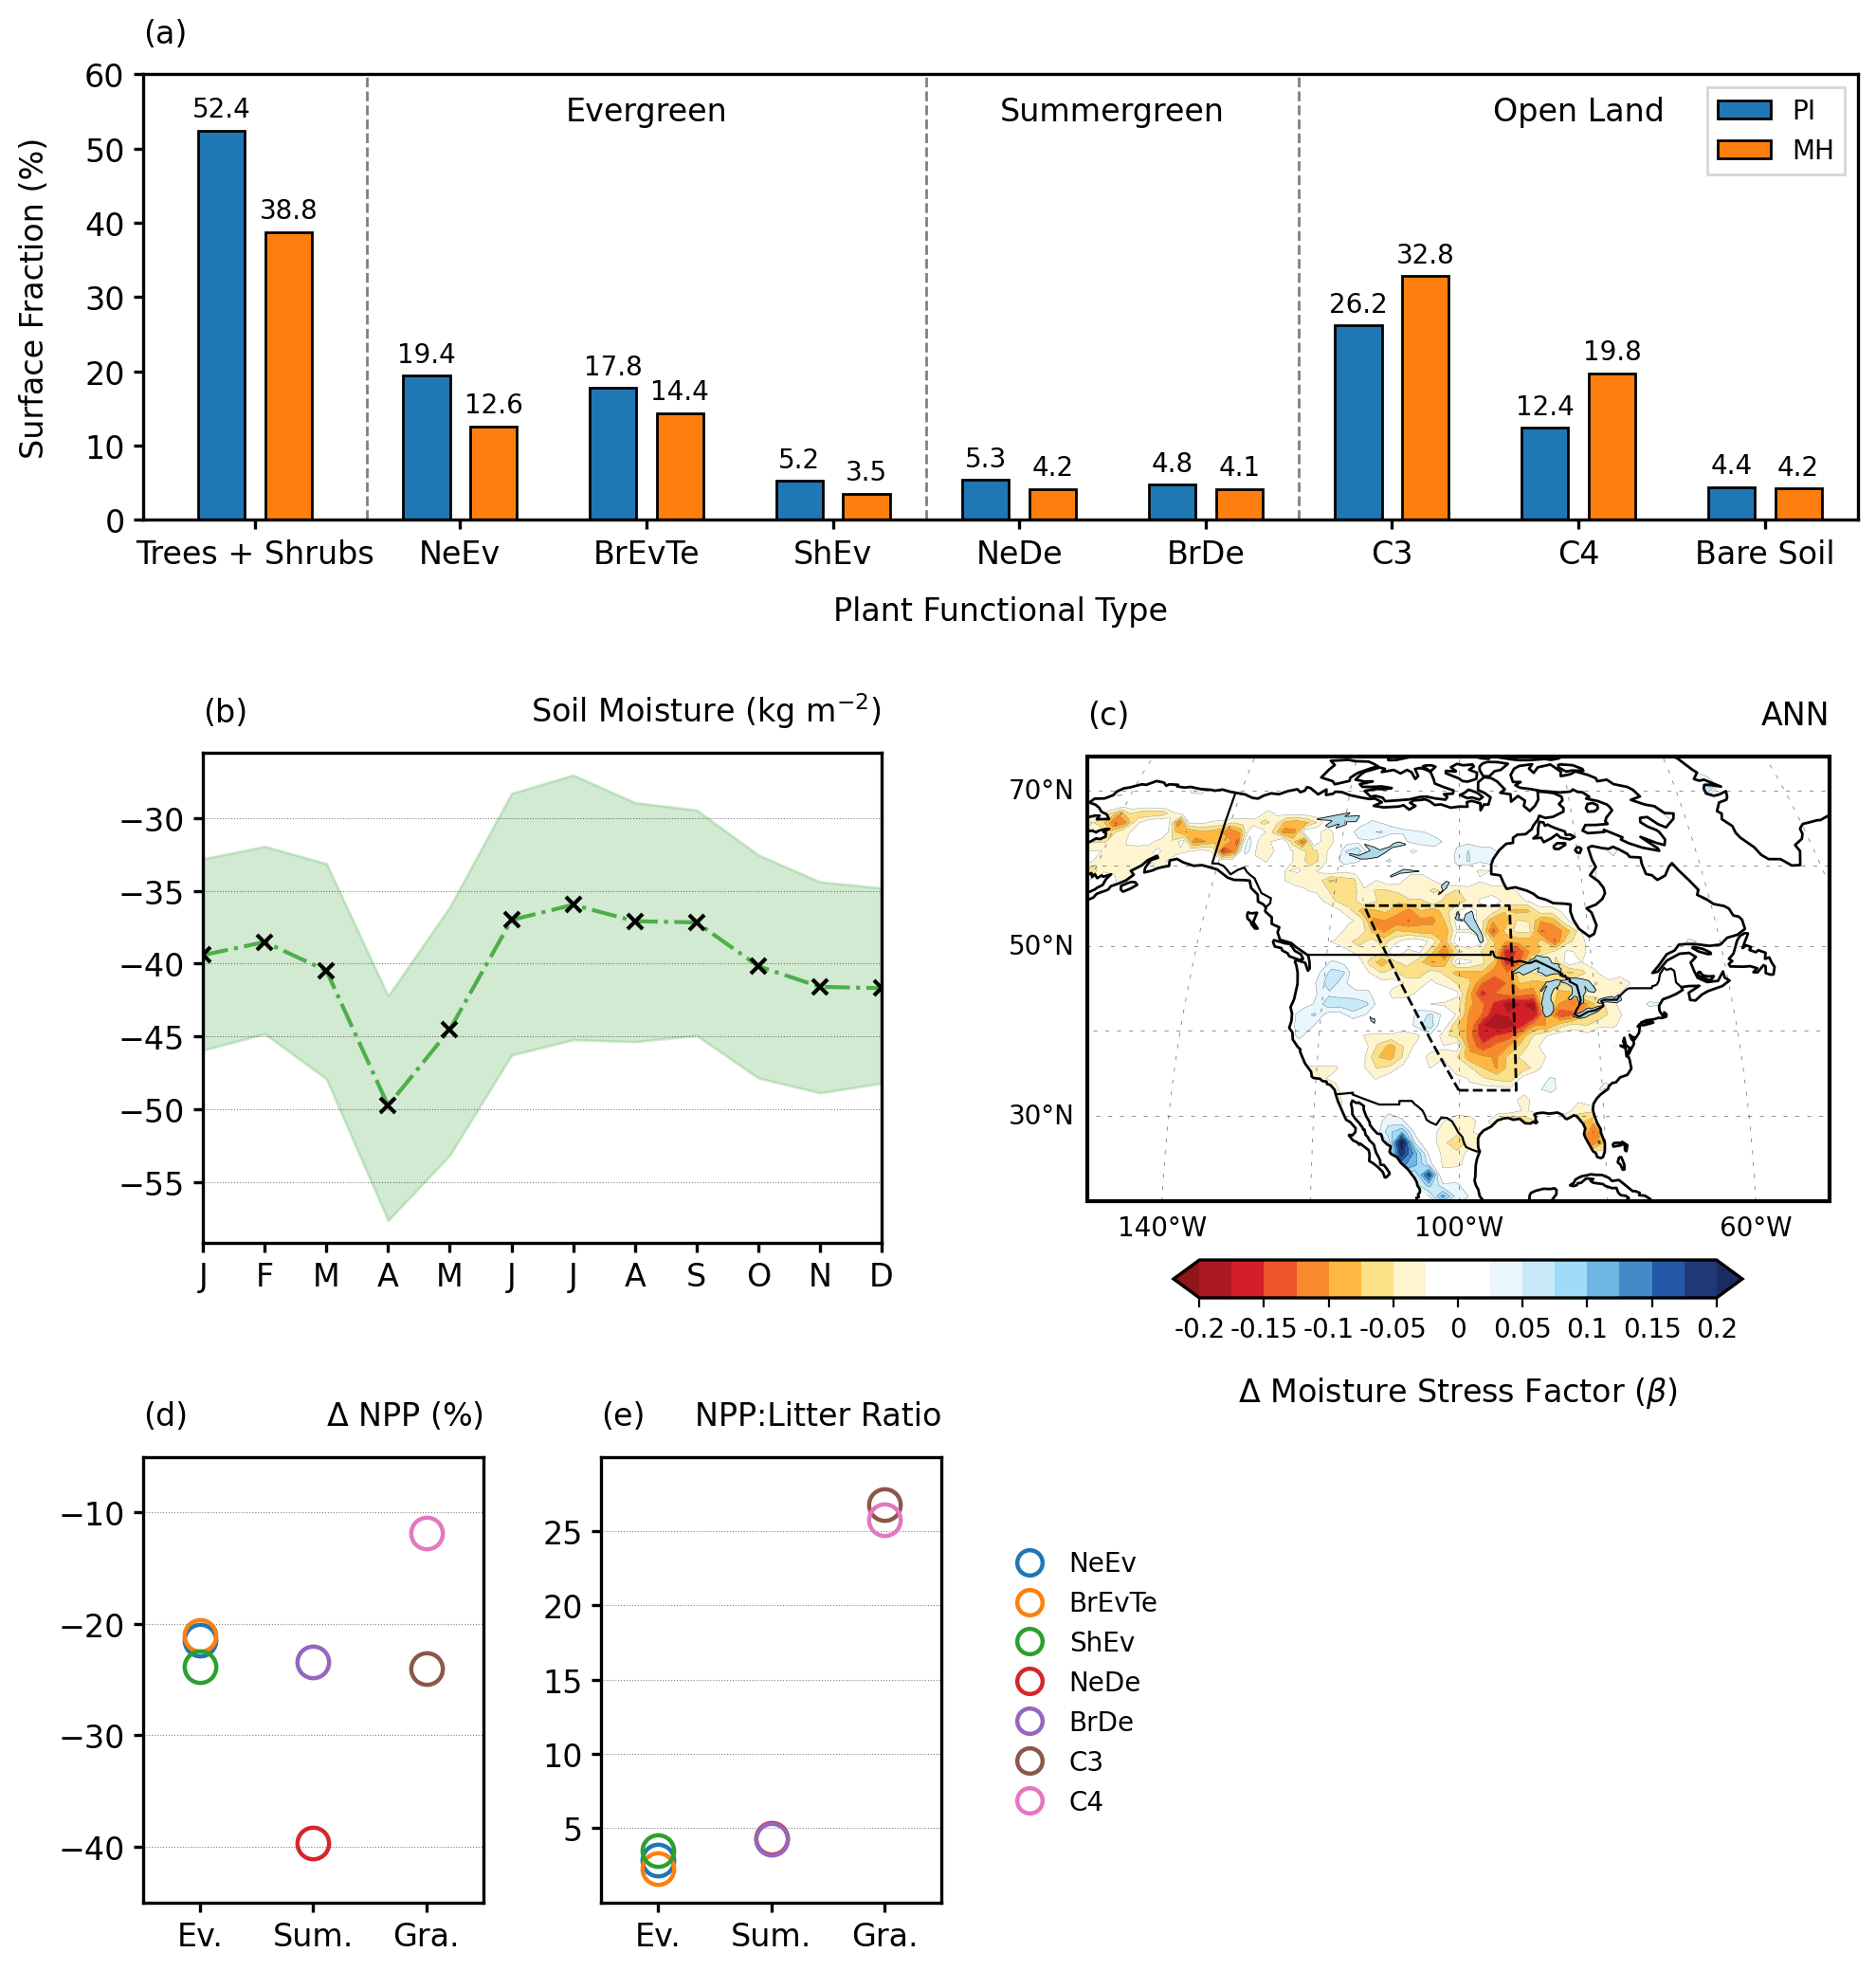

In [12]:
fig = plt.figure(figsize=(10, 10), dpi=200)
gs = gridspec.GridSpec(3, 8)

#--------------------------------------------------
# PFT Fractions Bar Chart
#--------------------------------------------------

ax = plt.subplot(gs[0, :])
PFTs = ["Trees + Shrubs", "NeEv", "BrEvTe", "ShEv", "NeDe", "BrDe", "C3", "C4", "Bare Soil"]
x1 = np.array([0, 1.1, 2.1, 3.1, 4.1, 5.1, 6.1, 7.1, 8.1]) # Positions for bars
np.arange(len(PFTs))
width = 0.25; dist = 0.18
x2 = np.array([0.6, 3.6, 5.6]) # Dividing lines between PFT sections

b1 = ax.bar(x1 - dist, pi_gp_sfracs, width, edgecolor="black", label="PI")
b2 = ax.bar(x1 + dist, mh_gp_sfracs, width, edgecolor="black", label="MH")
ax.bar_label(b1, fmt='{:.1f}', padding=3)
ax.bar_label(b2, fmt='{:.1f}', padding=3)

ax.vlines(x2, 0, 100, color="grey", ls="--", lw=1)

ax.annotate("Evergreen", (2.1, 55), ha="center", va="center", fontsize=12)
ax.annotate("Summergreen", (4.6, 55), ha="center", va="center", fontsize=12)
ax.annotate("Open Land", (7.1, 55), ha="center", va="center", fontsize=12)

ax.set_ylabel("Surface Fraction (%)", fontsize=12, labelpad=13)
ax.set_xlabel("Plant Functional Type", fontsize=12, labelpad=10)
ax.set_xticks(x1, PFTs, fontsize=12)
lgd = ax.legend(loc='upper right', fancybox=False)
ax.set_ylim(0, 60)
ax.set_xlim(-0.6, 8.6)
ax.tick_params("both", width=1.2)
ax.tick_params(axis="y", labelsize=12)

ax.set_title("(a)", loc="left", fontsize=12, pad=12)

ax.spines[["top", "bottom", "left", "right"]].set_linewidth(1.2)

#--------------------------------------------------
# GP Soil Moisture Seasonal Anomalies
#--------------------------------------------------

plot_time = np.arange(12)
xticklabs = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]
title = r"Soil Moisture (kg $\mathregular{m^{-2}}$)"

ax = plt.subplot(gs[1, :4])

ax.plot(plot_time, sm_mon_mean, lw=1.5, ls="dashdot", color="#4DAF4A", marker="x", mew=1.5, mec="black", zorder=5)
ax.fill_between(plot_time, sm_ci_upper, sm_ci_lower, alpha=0.25, color="#4DAF4A", lw=1)

ax.grid(True, which="major", axis="y", ls="dotted", color="black", alpha=0.5, lw=0.4, zorder=3)

ax.set_xticks(np.arange(0, 12), labels=xticklabs, fontsize=12)
ax.set_xlim(min(plot_time) ,max(plot_time))
ax.tick_params("both", width=1.2)
ax.tick_params(axis="y", labelsize=12)
if i == 0:
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:g}'))

ax.set_title(title, loc="right", fontsize=12, pad=12)
ax.set_title("(b)", loc="left", fontsize=12, pad=12)

ax.spines[["top", "bottom", "right", "left"]].set_linewidth(1.2)

#--------------------------------------------------
# Beta Anomalies
#--------------------------------------------------

lims, proj = [-150, -50, 20, 75], ccrs.Robinson(central_longitude=-100)
LON, LAT = np.meshgrid(MH_means.longitude, MH_means.latitude)
GP_region = umplt.umRegion("GP")

cmap = get_cpt.get_cmap("BlueWhiteOrangeRed.cpt", reverse=True); v = 0.2; levs = np.linspace(-v, v, 17); 
cbar_lab = r"$\Delta$ Moisture Stress Factor ($\beta$)"; cbar_axes_loc = (0.624, 0.33, 0.3, 0.02)

ax = plt.subplot(gs[1, 4:], projection=proj)
umplt.plotBaseMap(ax, lims, coastlw=1, borderlw=0.8, bordercol="black", ocean=True, lakes=True, spinelw=1.5)
umplt.plotGrid(ax, xlabeledlines=[-60, -100, -140], ylabeledlines=[30, 50, 70],
                xlines=[-40, -80, -120, -160], ylines=[40,60], lw=0.3, alph=0.5, labelsize=10)

cf1 = ax.contourf(LON, LAT, beta_anom, extend="both", levels=levs, cmap=cmap, transform=ccrs.PlateCarree(), transform_first=True, zorder=0)
c1 = ax.contour(LON, LAT, beta_anom, extend="both", levels=levs[~np.isclose(levs, 0.0)], colors="black", linestyles="dashed",
                linewidths=0.1 ,transform=ccrs.PlateCarree(), transform_first=True, zorder=0)

line_kws = {"color": "black", "linestyle": "dashed", "linewidth": 1, "zorder": 0}
GP_region.plot(ax=ax,line_kws=line_kws, add_coastlines=False, add_label=False)

cbaxes = fig.add_axes(cbar_axes_loc)
cbar = plt.colorbar(cf1, extend='both', orientation='horizontal', ticks=np.linspace(-v, v, 9), cax=cbaxes)
cbar.outline.set_linewidth(1.2)
cbar.set_ticks(np.linspace(-v, v, 9), labels=["{:g}".format(x) for x in cbar.get_ticks()], fontsize=10)
cbar.set_label(label=cbar_lab, size=12, labelpad=12)

ax.set_title("(c)", loc="left", fontsize=12, pad=12)
ax.set_title("ANN", loc="right", fontsize=12, pad=12)

#--------------------------------------------------
# NPP Scatter Plots
#--------------------------------------------------

pfts_to_plot = ["NeEv", "BrEvTe", "ShEv", "NeDe", "BrDe", "C3Gr", "C4Gr"]
x = np.array([1, 1, 1, 2, 2, 3, 3])
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']
pointlabs = ["NeEv", "BrEvTe", "ShEv", "NeDe", "BrDe", "C3", "C4"]
xlabels = ["Ev.", "Sum.", "Gra."]

variables = [gp_npp_anom, gp_npp_to_litter]
windows = [gs[2, :2], gs[2, 2:4]]
titles = [r"$\Delta$ NPP (%)", r"NPP:Litter Ratio"]
ylims = [(-45, -5), (0, 30)]
yticks = [np.linspace(-10, -40, 4), np.linspace(5, 25, 5)]
labs = ["d", "e"]
plot_data = zip(variables, windows, titles, ylims, yticks, labs)

for i, (variable, plot_window, title, ylim, ytick, lab) in enumerate(plot_data):
    ax = plt.subplot(plot_window)

    y = variable.sel(pseudo=pfts_to_plot)
    for j, (xi, yi, col) in enumerate(zip(x, y.values, colors)):
        ax.plot(xi, yi, marker="o", mfc="none", mec=col, ls="none", ms=12, label=pointlabs[j], mew=1.6)

    ax.set_title(title, loc="right", pad=12)
    ax.set_ylim(ylim[0], ylim[1])
    ax.set_xlim(0.5, 3.5)
    ax.set_xticks(np.unique(x), xlabels)
    ax.set_yticks(ytick)
    ax.tick_params(axis="both", width=1.2, labelsize=12)

    ax.set_title(f"({lab})", loc="left", pad=12)

    ax.grid(True, which="major", axis="y", ls="dotted", color="black", alpha=0.5, lw=0.4, zorder=3)

    ax.spines[["top", "bottom", "left", "right"]].set_linewidth(1.2)

handles, labels = ax.get_legend_handles_labels()
lgaxes = fig.add_axes((0.525, 0.057, 0.1, 0.2))
lgd = lgaxes.legend(handles, labels, loc="center", frameon=False, markerscale=0.8, handletextpad=0.5)
lgaxes.set_axis_off()
 
plt.tight_layout()

ax = umplt.find_axis(fig, title="Soil Moisture", contains=True)
umplt.ax_adjust(ax, shrinkx=0.85, shrinky=1.1)
axes = fig.get_axes()
umplt.ax_adjust(axes[1:], shifty=-0.03)
umplt.ax_adjust(axes[2:4], shifty=0.01)
umplt.ax_adjust(axes[-3:], shifty=-0.02)

plt.show()